# `In the name of Allah, the most Gracious, the most Merciful`

# FEATURE ENGINEERING & POLYNOMIAL REGRESSION
## Complete Lab Summary

---

## TABLE OF CONTENTS

1. [Introduction](#introduction)
2. [What is Feature Engineering?](#what-is-feature-engineering)
3. [Polynomial Features](#polynomial-features)
4. [Selecting Features](#selecting-features)
5. [Feature Scaling with Polynomial Features](#feature-scaling-with-polynomial-features)
6. [Complex Functions](#complex-functions)
7. [Complete Code](#complete-code)
8. [Key Takeaways](#key-takeaways)

---

##  [Introduction](#introduction)

### The Problem

Linear regression can only fit **straight lines**:
$$f_{\mathbf{w},b} = w_0x_0 + w_1x_1 + ... + w_{n-1}x_{n-1} + b$$

But real-world data is often **non-linear** (curved)!

### The Solution: Feature Engineering

> **Feature Engineering** = Creating new features from existing data to capture non-linear relationships.

**Example:**
```python
# Instead of using x only:
X = [x]

# We engineer new features:
X = [x, x², x³, ...]

```
**That's called `Polynomial`**

PART 1: SIMPLE POLYNOMIAL (y = 1 + x^2)

1A: Using x only (Linear Regression)
Iter      0: Cost = 1657.563294
Iter    100: Cost = 694.549107
Iter    200: Cost = 588.475448
Iter    300: Cost = 526.413761
Iter    400: Cost = 490.102643
Iter    500: Cost = 468.857696
Iter    600: Cost = 456.427680
Iter    700: Cost = 449.155114
Iter    800: Cost = 444.900073
Iter    900: Cost = 442.410529

w,b found: w: [18.7], b: -52.0834

1B: Using x^2 (Polynomial)
Iter      0: Cost = 7329.218075
Iter   1000: Cost = 0.224844
Iter   2000: Cost = 0.222795
Iter   3000: Cost = 0.220764
Iter   4000: Cost = 0.218752
Iter   5000: Cost = 0.216758
Iter   6000: Cost = 0.214782
Iter   7000: Cost = 0.212824
Iter   8000: Cost = 0.210884
Iter   9000: Cost = 0.208962

w,b found: w: [1.], b: 0.0490


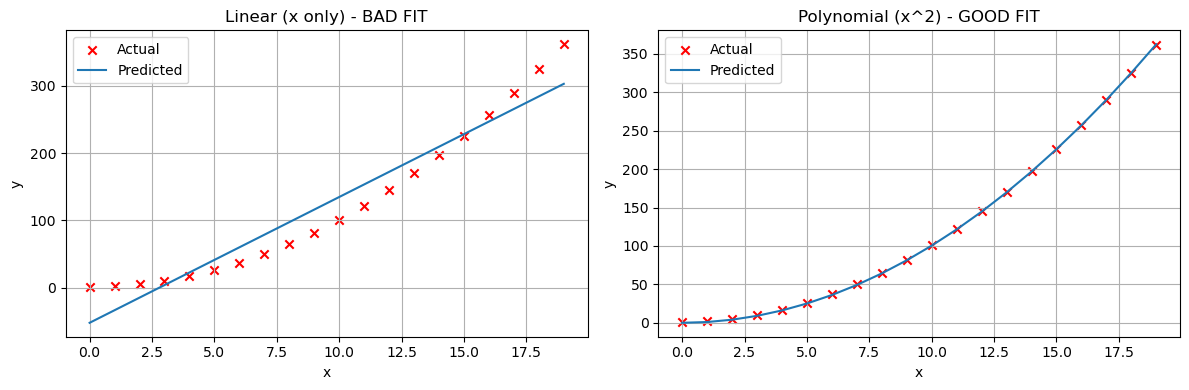


PART 2: MULTIPLE POLYNOMIAL FEATURES (x, x^2, x^3)


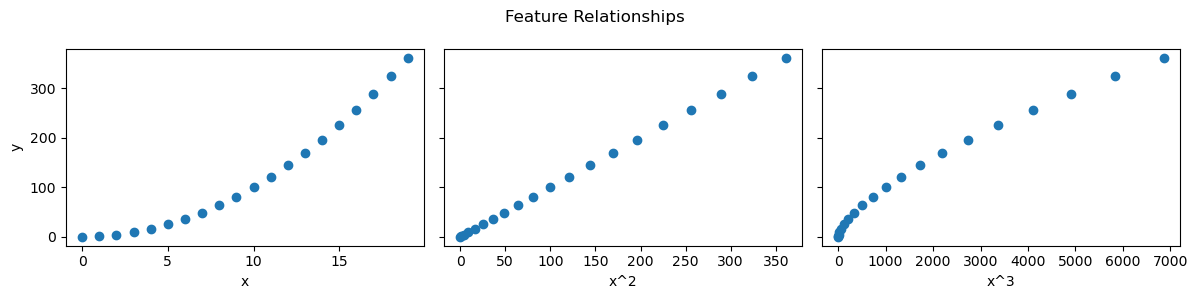


Training with x, x^2, x^3:
Iter      0: Cost = 1140.292404
Iter   1000: Cost = 328.539492
Iter   2000: Cost = 280.443420
Iter   3000: Cost = 239.388632
Iter   4000: Cost = 204.344281
Iter   5000: Cost = 174.430437
Iter   6000: Cost = 148.895991
Iter   7000: Cost = 127.099798
Iter   8000: Cost = 108.494575
Iter   9000: Cost = 92.613164

w,b found: w: [0.08 0.54 0.03], b: 0.0106

Weights: [0.08 0.54 0.03]
Bias: 0.0106
Model: y = 0.08x + 0.54x^2 + 0.03x^3 + 0.0106


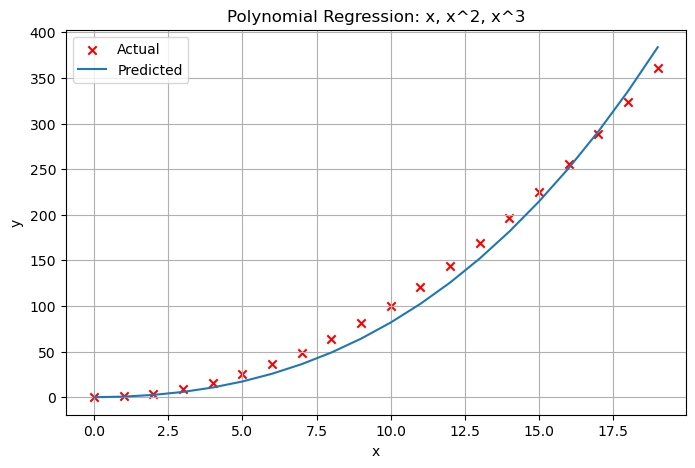


PART 3: FEATURE SCALING WITH POLYNOMIAL FEATURES

Before scaling - Peak to Peak: [  19  361 6859]
After scaling - Peak to Peak: [3.3  3.18 3.28]

Training with scaled features:
Iter      0: Cost = 9421.466803
Iter  10000: Cost = 0.390938
Iter  20000: Cost = 0.027839
Iter  30000: Cost = 0.001982
Iter  40000: Cost = 0.000141
Iter  50000: Cost = 0.000010
Iter  60000: Cost = 0.000001
Iter  70000: Cost = 0.000000
Iter  80000: Cost = 0.000000
Iter  90000: Cost = 0.000000

w,b found: w: [5.27e-05 1.13e+02 8.43e-05], b: 123.5000

Weights: [5.27e-05 1.13e+02 8.43e-05]
Bias: 123.5000


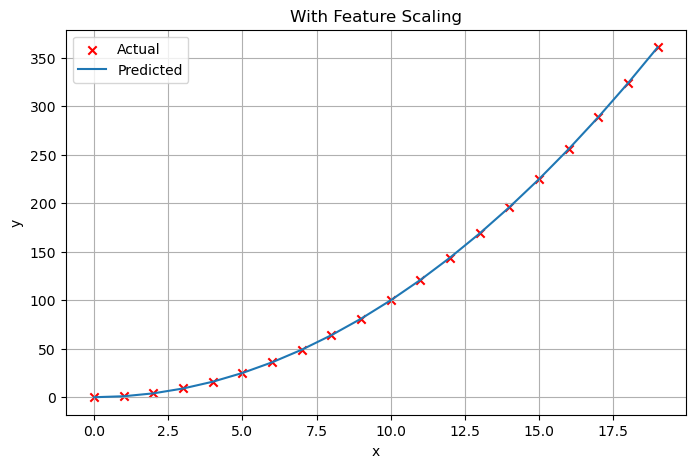


PART 4: COMPLEX FUNCTION (COSINE)

Training complex function with 13 polynomial features...
Iter      0: Cost = 0.220188
Iter 100000: Cost = 0.017007
Iter 200000: Cost = 0.012760
Iter 300000: Cost = 0.009730
Iter 400000: Cost = 0.007564
Iter 500000: Cost = 0.006014
Iter 600000: Cost = 0.004903
Iter 700000: Cost = 0.004104
Iter 800000: Cost = 0.003527
Iter 900000: Cost = 0.003110

w,b found: w: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82], b: -0.0073

Weights: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82]
Bias: -0.0073


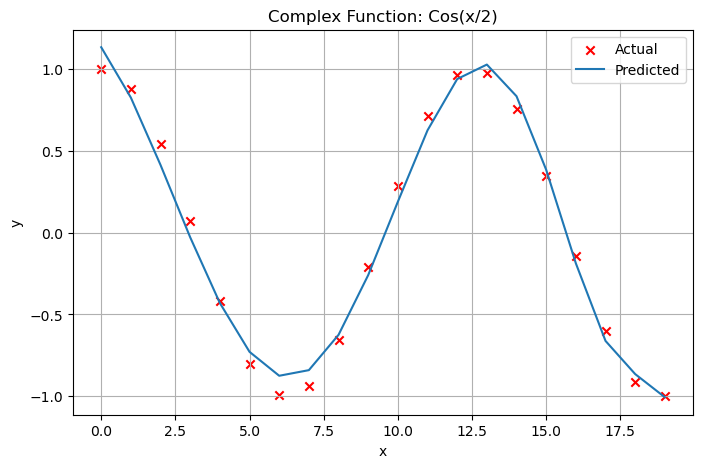


SUMMARY OF RESULTS

1. Simple Linear (x only):    Failed (can't capture curve)
2. Polynomial (x^2):          Perfect fit
3. Multiple Features (x, x^2, x^3): Good fit (x^2 most important)
4. With Feature Scaling:      Faster convergence
5. Complex (13 features):     Fit any curve

KEY TAKEAWAYS:
1. Polynomial features allow linear regression to fit non-linear data
2. Feature engineering creates new features from existing ones
3. Weight values indicate feature importance
4. Feature scaling is crucial when using polynomial features
5. Be careful of overfitting (too many features)


DONE. All code executed successfully.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2)

def run_gradient_descent_feng(X, y, iterations, alpha):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    J_history = []
    
    for i in range(iterations):
        dj_dw = np.zeros(n)
        dj_db = 0
        
        for j in range(m):
            err = (np.dot(X[j], w) + b) - y[j]
            for k in range(n):
                dj_dw[k] = dj_dw[k] + err * X[j, k]
            dj_db = dj_db + err
        
        dj_dw = dj_dw / m
        dj_db = dj_db / m
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        predictions = X @ w + b
        error = predictions - y
        cost = np.mean(error ** 2) / 2
        J_history.append(cost)
        
        if i % max(1, iterations // 10) == 0:
            print(f"Iter {i:6d}: Cost = {cost:.6f}")
    
    print(f"\nw,b found: w: {w}, b: {b:.4f}")
    return w, b

def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# ============================================
# PART 1: SIMPLE POLYNOMIAL (y = 1 + x^2)
# ============================================

print("="*60)
print("PART 1: SIMPLE POLYNOMIAL (y = 1 + x^2)")
print("="*60)

x = np.arange(0, 20, 1)
y = 1 + x**2

print("\n1A: Using x only (Linear Regression)")
X1 = x.reshape(-1, 1)
model_w1, model_b1 = run_gradient_descent_feng(X1, y, iterations=1000, alpha=1e-2)

print("\n1B: Using x^2 (Polynomial)")
X2 = x**2
X2 = X2.reshape(-1, 1)
model_w2, model_b2 = run_gradient_descent_feng(X2, y, iterations=10000, alpha=1e-5)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, X1 @ model_w1 + model_b1, label='Predicted')
plt.title('Linear (x only) - BAD FIT')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, X2 @ model_w2 + model_b2, label='Predicted')
plt.title('Polynomial (x^2) - GOOD FIT')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# PART 2: MULTIPLE POLYNOMIAL FEATURES
# ============================================

print("\n" + "="*60)
print("PART 2: MULTIPLE POLYNOMIAL FEATURES (x, x^2, x^3)")
print("="*60)

x = np.arange(0, 20, 1)
y = x**2

X3 = np.c_[x, x**2, x**3]
X_features = ['x', 'x^2', 'x^3']

fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(3):
    ax[i].scatter(X3[:, i], y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('y')
plt.suptitle('Feature Relationships')
plt.tight_layout()
plt.show()

print("\nTraining with x, x^2, x^3:")
model_w3, model_b3 = run_gradient_descent_feng(X3, y, iterations=10000, alpha=1e-7)

print(f"\nWeights: {model_w3}")
print(f"Bias: {model_b3:.4f}")
print(f"Model: y = {model_w3[0]:.2f}x + {model_w3[1]:.2f}x^2 + {model_w3[2]:.2f}x^3 + {model_b3:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, X3 @ model_w3 + model_b3, label='Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression: x, x^2, x^3')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# PART 3: FEATURE SCALING
# ============================================

print("\n" + "="*60)
print("PART 3: FEATURE SCALING WITH POLYNOMIAL FEATURES")
print("="*60)

X_raw = np.c_[x, x**2, x**3]
print(f"\nBefore scaling - Peak to Peak: {np.ptp(X_raw, axis=0)}")

X_scaled, mu, sigma = zscore_normalize_features(X_raw)
print(f"After scaling - Peak to Peak: {np.ptp(X_scaled, axis=0)}")

print("\nTraining with scaled features:")
model_w4, model_b4 = run_gradient_descent_feng(X_scaled, y, iterations=100000, alpha=1e-1)

print(f"\nWeights: {model_w4}")
print(f"Bias: {model_b4:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, X_scaled @ model_w4 + model_b4, label='Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.title('With Feature Scaling')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# PART 4: COMPLEX FUNCTION
# ============================================

print("\n" + "="*60)
print("PART 4: COMPLEX FUNCTION (COSINE)")
print("="*60)

x = np.arange(0, 20, 1)
y = np.cos(x/2)

X5 = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X5_scaled, mu5, sigma5 = zscore_normalize_features(X5)

print("\nTraining complex function with 13 polynomial features...")
model_w5, model_b5 = run_gradient_descent_feng(X5_scaled, y, iterations=1000000, alpha=1e-1)

print(f"\nWeights: {model_w5}")
print(f"Bias: {model_b5:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, X5_scaled @ model_w5 + model_b5, label='Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Complex Function: Cos(x/2)')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# SUMMARY
# ============================================

print("\n" + "="*60)
print("SUMMARY OF RESULTS")
print("="*60)

print("""
1. Simple Linear (x only):    Failed (can't capture curve)
2. Polynomial (x^2):          Perfect fit
3. Multiple Features (x, x^2, x^3): Good fit (x^2 most important)
4. With Feature Scaling:      Faster convergence
5. Complex (13 features):     Fit any curve

KEY TAKEAWAYS:
1. Polynomial features allow linear regression to fit non-linear data
2. Feature engineering creates new features from existing ones
3. Weight values indicate feature importance
4. Feature scaling is crucial when using polynomial features
5. Be careful of overfitting (too many features)
""")

print("\nDONE. All code executed successfully.")